In [440]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad


import xobjects as xo
import xtrack as xt
import xpart as xp
import xcoll as xc

import pandas as pd

# Make a context and get a buffer
context = xo.ContextCpu()         # For CPU
# context = xo.ContextCupy()      # For CUDA GPUs
# context = xo.ContextPyopencl()  # For OpenCL GPUs

In [441]:
num_part = int(10000)
x_init = 0.002 * np.ones(num_part)
px_init = np.zeros(num_part)
y_init   = np.zeros(num_part)
py_init  = np.zeros(num_part)

def initialize_particles(context, num_particles=num_part):
    return xp.Particles(
        _context=context,
        x=x_init,  
        px=px_init, 
        y=y_init,
        py=py_init,
        delta=0,
        p0c=4e11
    )
    

In [442]:
# Define the crystal properties (initial values)
length = 0.002
material = xc.materials.SiliconCrystal
bending_angle = 440e-6 / 5
width = 0.002
height = 0.05
side = '+'
miscut = 0.0
lattice = 'strip'
jaw = 0.001

In [443]:
# Dataframe to store particle tracking information
columns = ['iteration', 'particle_id', 'x', 'px']
tracking_data = pd.DataFrame(columns=columns)

In [444]:

min_angle = -20
max_angle = 20
steps = 1
# Define the range of bending angles to iterate over
impacting_angles = [i * 1e-6 for i in range(min_angle, max_angle, steps)]  # Example: 100 µrad to 200 µrad in 10 µrad steps


In [445]:
# List to collect all tracking data
tracking_data_list = []

# Loop over bending angles
for iteration, angle in enumerate(impacting_angles):
    # Create the crystal with the current bending angle
    coll = xc.EverestCrystal(
        length=length,
        material=material,
        bending_angle=bending_angle,
        width=width,
        height=height,
        side=side,
        miscut=miscut,
        lattice=lattice,
        tilt = angle,    #IMPORTANT
        jaw=jaw,
        _context=context
    )
    
    # Initialize a new beam of particles for this iteration
    part = initialize_particles(context)
    part_init = part.copy()
    
    # Track particles through the crystal
    coll.track(part)  # Updates the particle states in place
    
    # Collect particle data for this iteration
    for i in range(len(part.x)):
        tracking_data_list.append({
            'iteration': iteration,
            'particle_id': i,
            'x': part.x[i],
            'px': part.px[i],
            'px_init': part_init.px[i],
            'angle': angle
        })
    print(str(iteration))
# Convert the collected data into a DataFrame
tracking_data = pd.DataFrame(tracking_data_list)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39


In [446]:
# Perform analysis or save the DataFrame
print(tracking_data.head())


   iteration  particle_id      x        px  px_init    angle
0          0            0  0.002 -0.000016      0.0 -0.00002
1          0            1  0.002 -0.000011      0.0 -0.00002
2          0            2  0.002 -0.000012      0.0 -0.00002
3          0            3  0.002 -0.000017      0.0 -0.00002
4          0            4  0.002 -0.000011      0.0 -0.00002


In [447]:
tracking_data

,iteration,particle_id,x,px,px_init,angle
0,0,0,0.002,-1.600784e-05,0.0,-0.000020
1,0,1,0.002,-1.120663e-05,0.0,-0.000020
2,0,2,0.002,-1.168383e-05,0.0,-0.000020
3,0,3,0.002,-1.676000e-05,0.0,-0.000020
4,0,4,0.002,-1.119609e-05,0.0,-0.000020
...,...,...,...,...,...,...
399995,39,9995,0.002,1.219610e-06,0.0,0.000019
399996,39,9996,0.002,-1.281214e-06,0.0,0.000019
399997,39,9997,0.002,-1.793397e-06,0.0,0.000019
399998,39,9998,0.002,-9.691791e-07,0.0,0.000019


The bending angle of the crystal is: 88.0 murad
The crystal angle is: -20.0 murad
crystal_angle: -20.0 mrad
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 0 1 1 1 0 0 0 0 0
 0 0 1 0 1 1 0 1 0 0 0 0 0 3 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 1 1 0
 1 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 3 0 0 2 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0
 1 0 1 2 1 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Bin with biggest count: 124
Efficiency of 0 iteration: 0.51%
The crystal angle is: -18.999999999999996 murad
crystal_angle: -18.999999999999996 mrad
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0

/var/folders/vc/njn3rgb96cq7_32jmcfzppkm0000gn/T/ipykernel_22454/3031199265.py:74: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 6))


The crystal angle is: 1.0 murad
crystal_angle: 1.0 mrad
[ 0  0  1  0  0  0  0  0  0  2  0  1  0  0  1  1  0  0  0  1  1  0  0  1
  1  1  0  0  0  1  2  1  0  0  2  1  1  0  1  1  2  0  0  1  1  1  1  1
  0  0  1  1  0  2  0  0  1  0  0  1  1  5  0  2  2  1  3  1  2  1  1  1
  1  1  0  3  0  1  0  1  0  1  1  1  1  1  2  2  0  2  0  4  5  3  2  2
  2  2  2  4  2  6  4  5  2  3  5  2  4  1  1  5  3  5  8  2  3  2  3  2
  3  5  3  7  8  0  6 11  6  7 12  3 11  2  8  9  8  8  7  7  8 13  9  5
  5  8 13 11  9 10  7 11 14 12 10  7 13 17 11 16 11 17 19 24 17  9 22 15
 20 15 21 12 14 19 12 18 16 26 18 20 24 17 17 20 19 14 30 16 19 22 29 22
 24 24 24 20 23 17 25 27 39 22 27 25 24 30 29 23 28 25 31 29 28 33 35 41
 33 47 35 30 37 39 37 26 23 39 28 45 33 32 37 30 38 35 33 43 34 35 27 36
 49 44 32 37 54 41 35 49 37 50 45 39 53 40 40 38 47 43 43 45 58 55 46 46
 56 47 40 48 40 48 44 49 58 39 40 42 41 33 40 48 42 52 38 47 38 59 45 49
 40 45 37 42 40 43 40 34 28 45 43 42 36 49 40 47 31 44 49 41 41 41 3

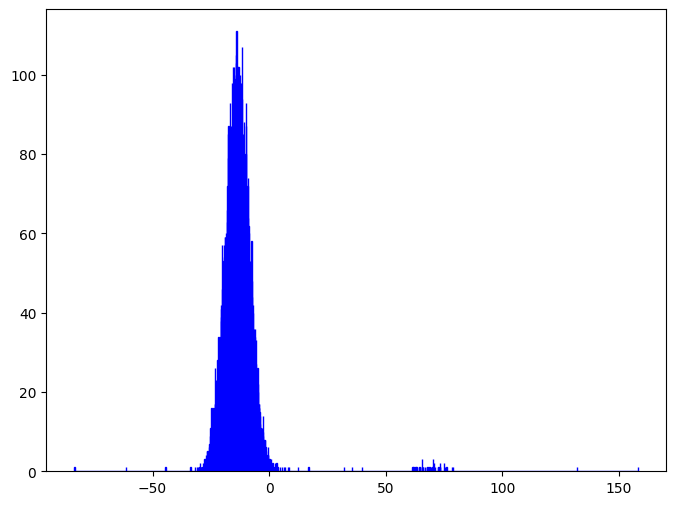

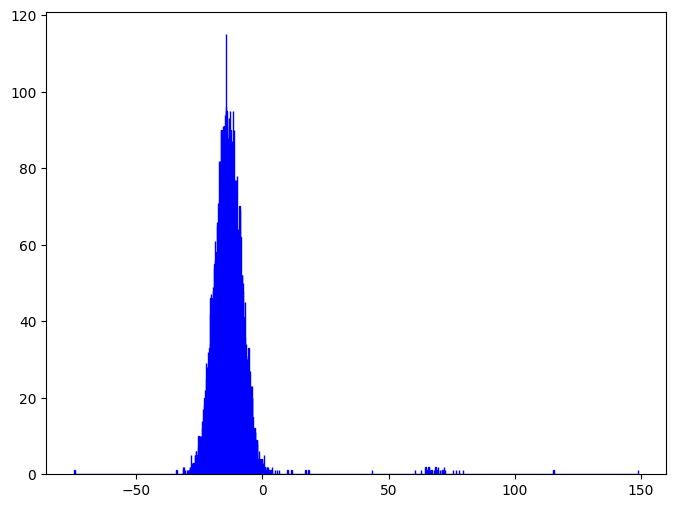

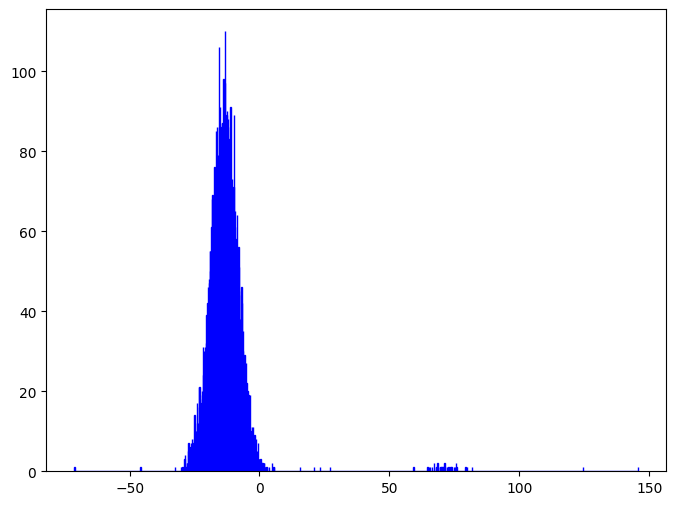

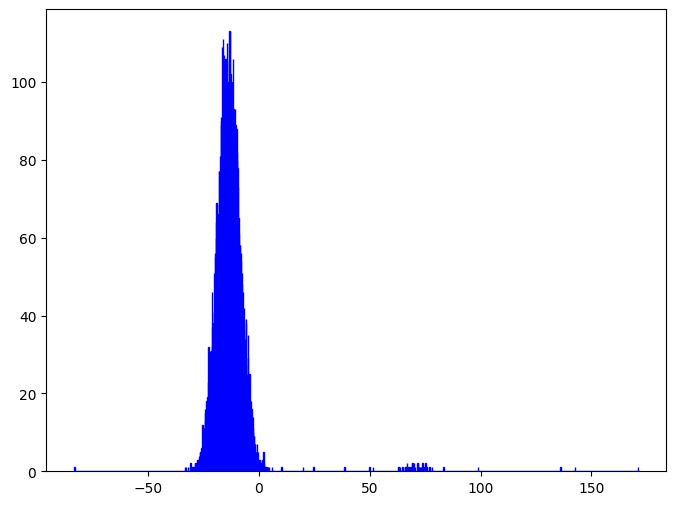

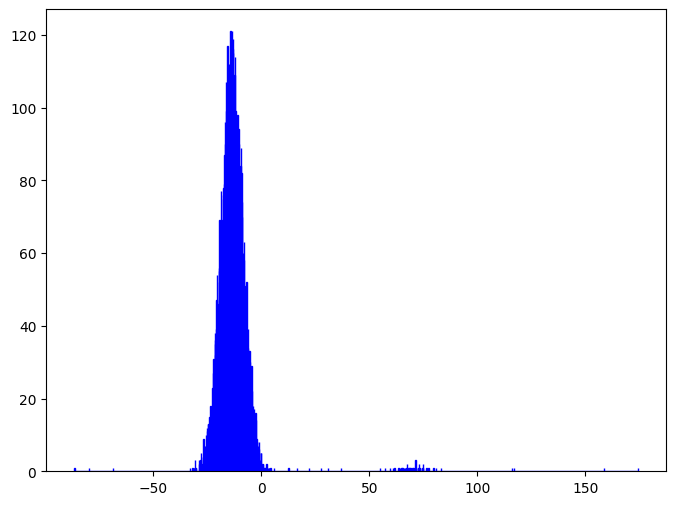

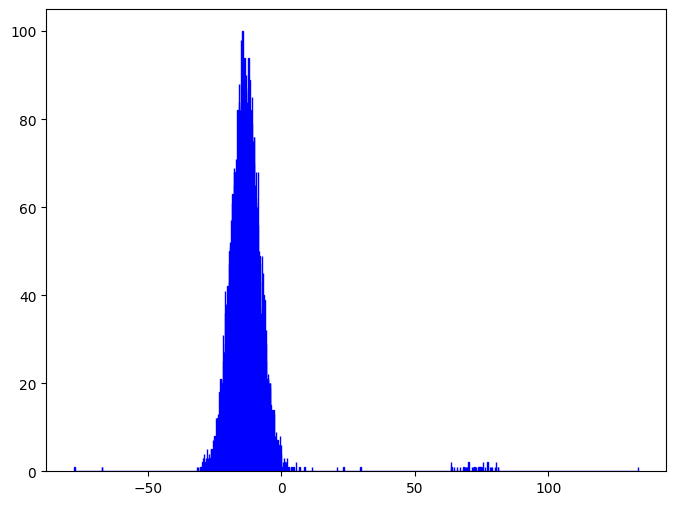

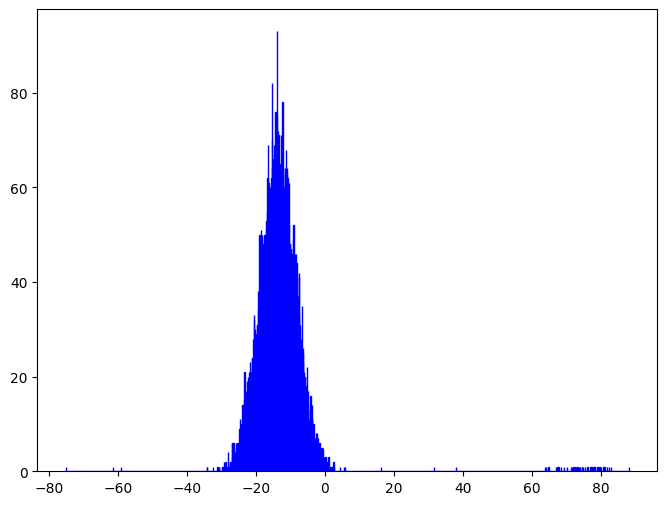

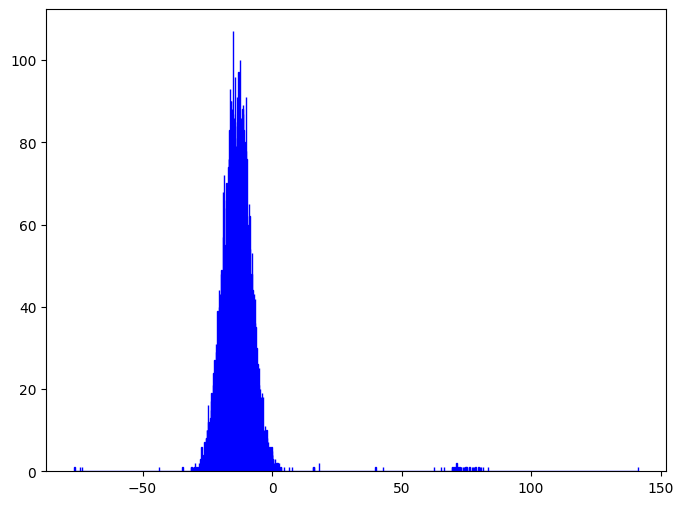

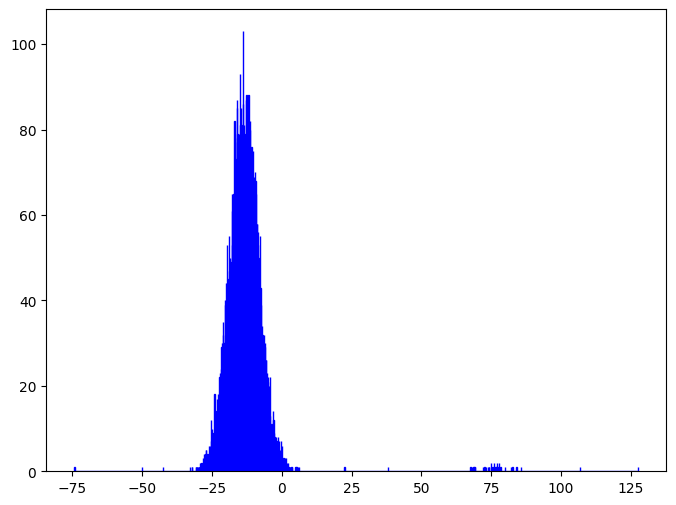

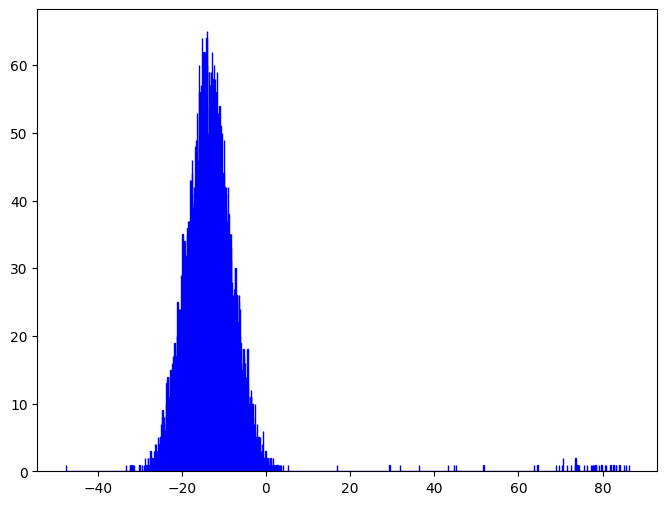

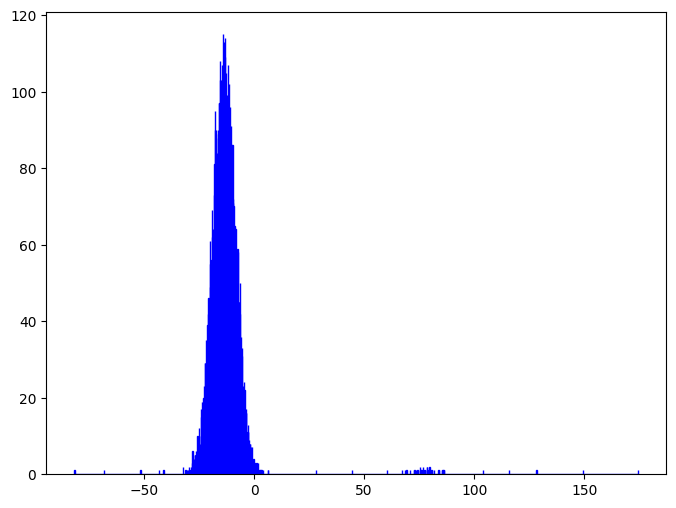

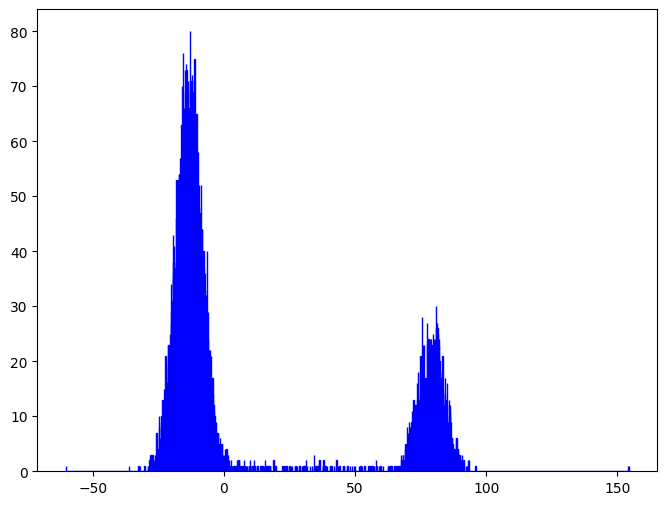

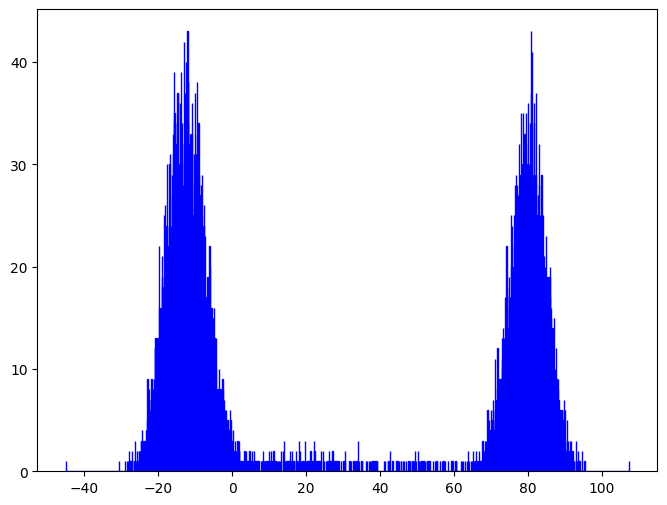

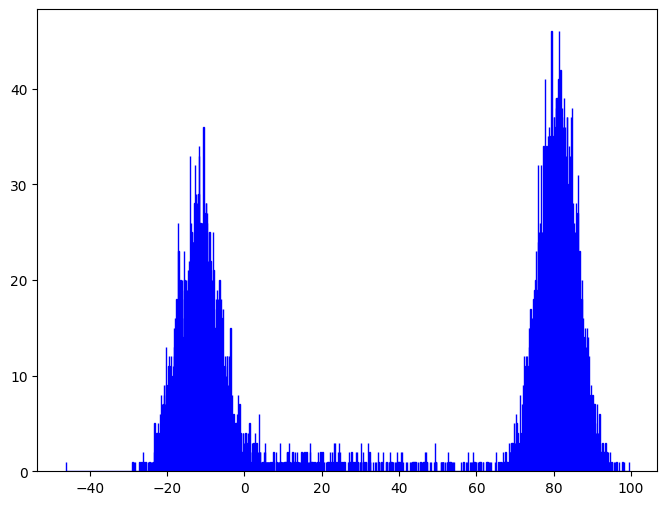

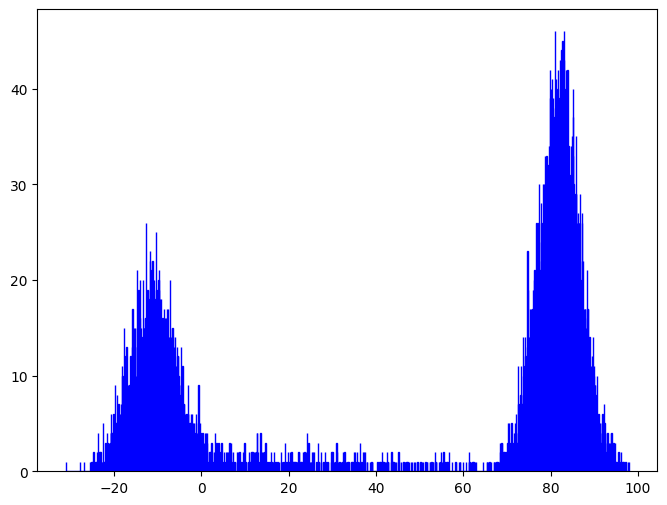

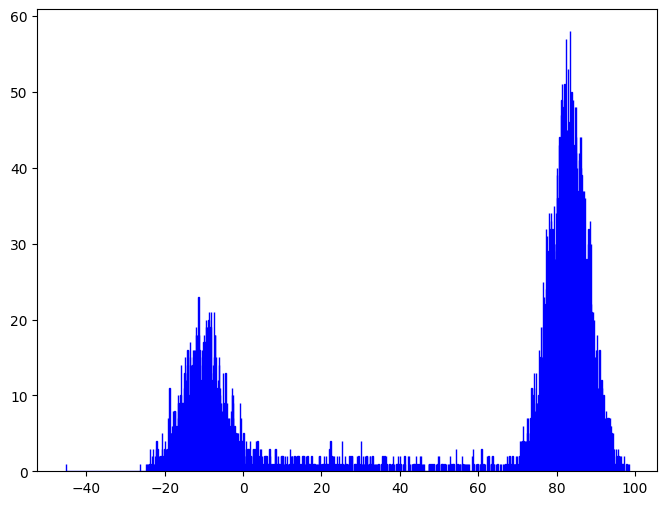

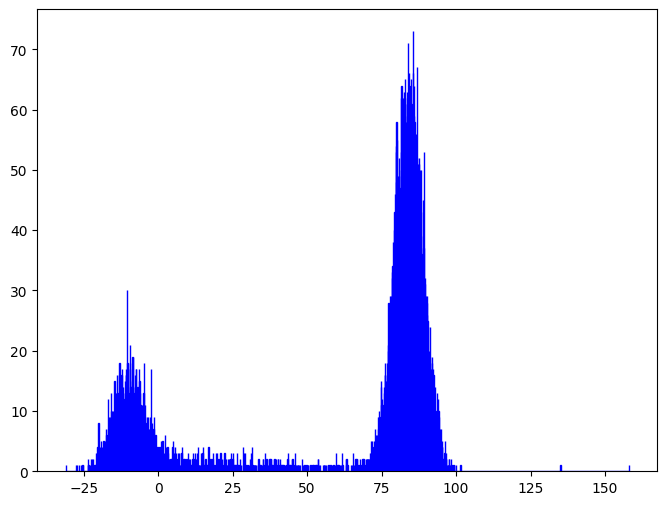

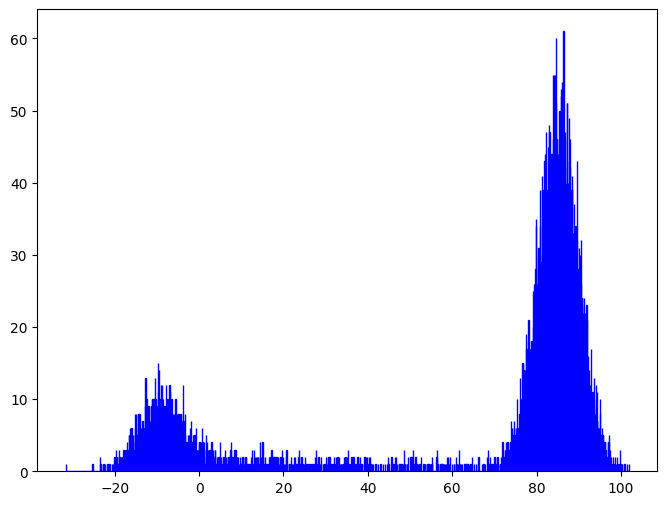

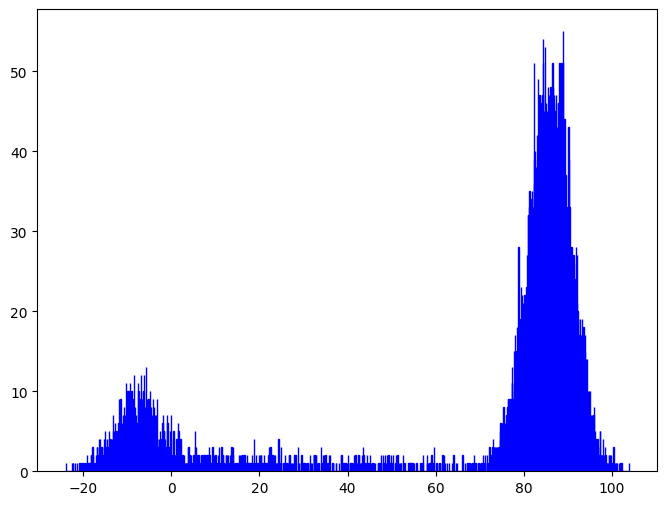

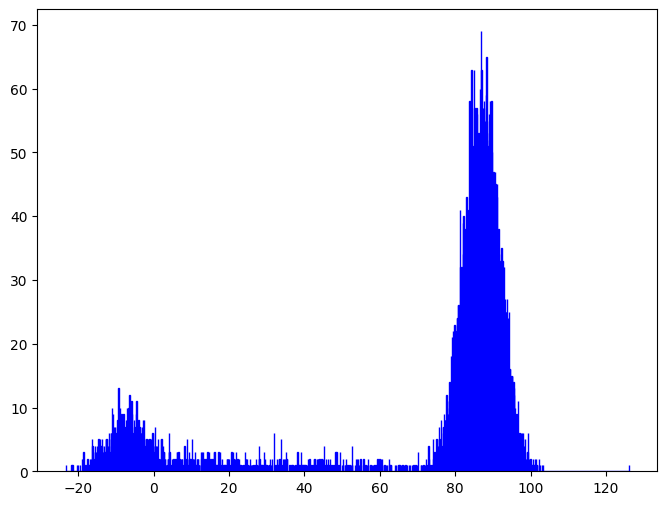

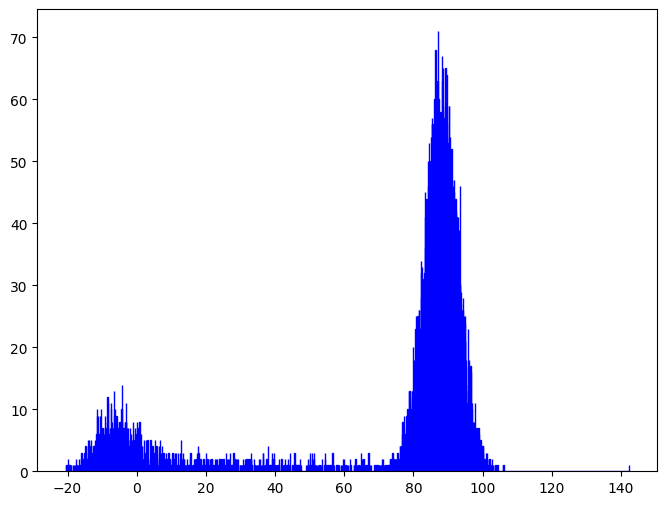

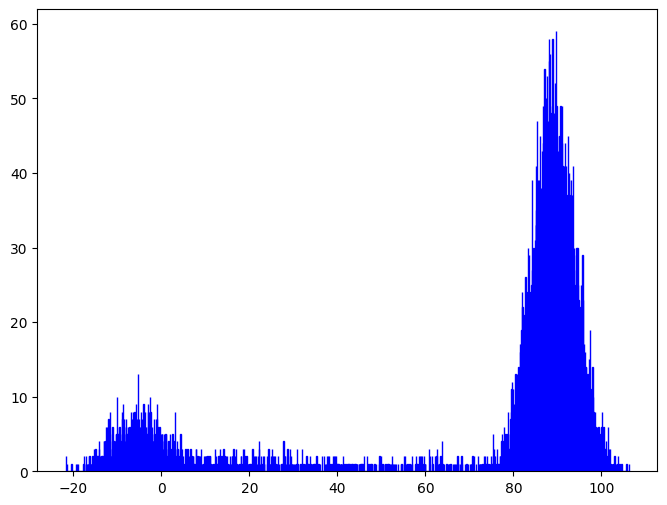

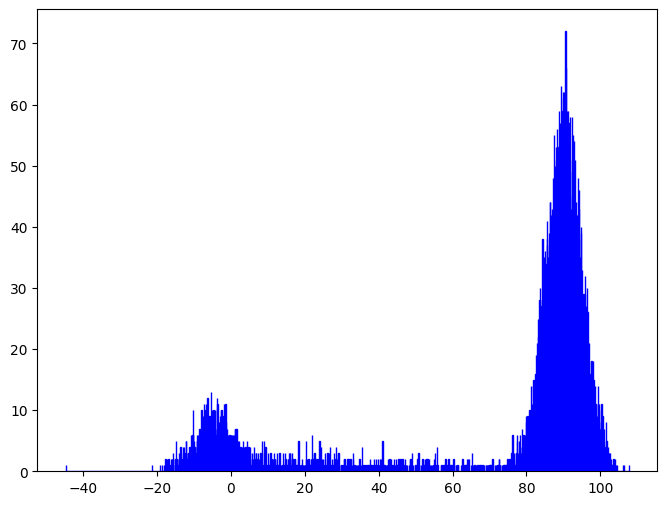

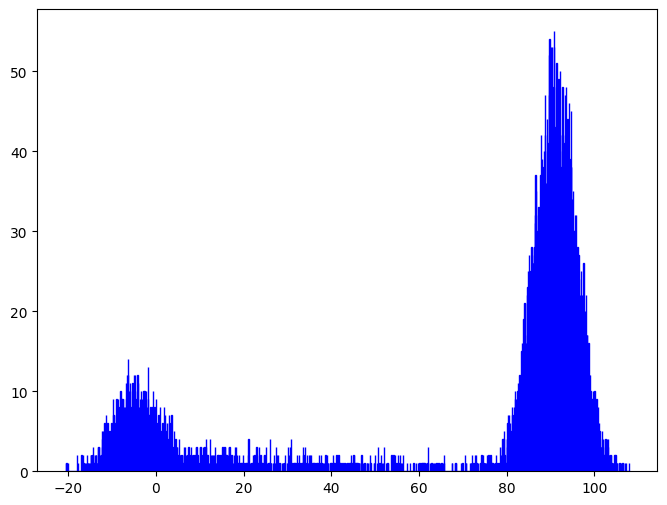

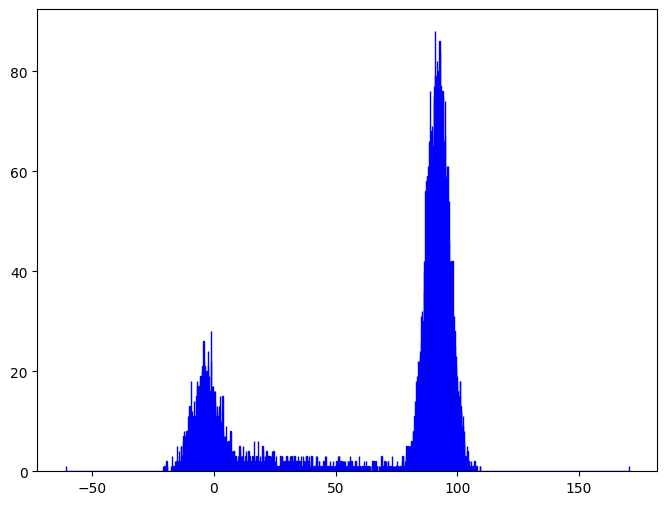

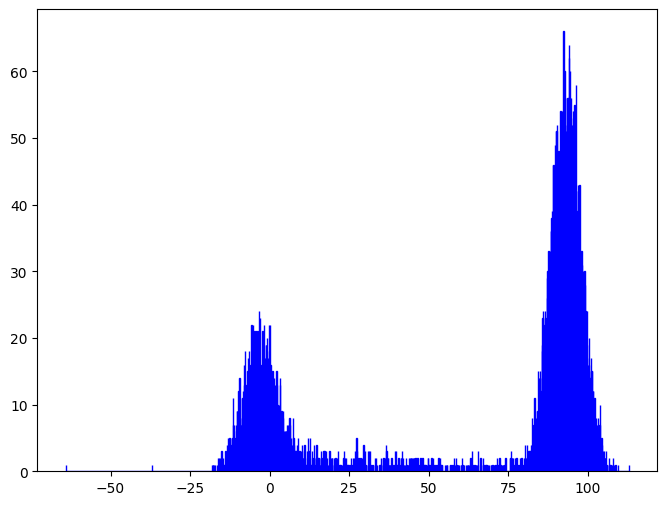

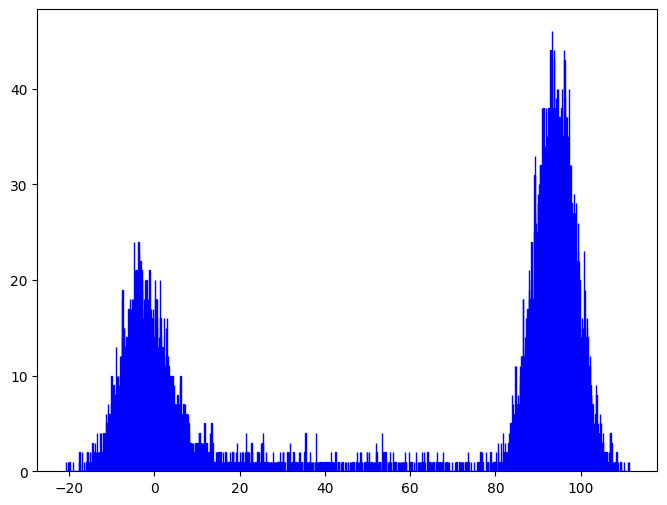

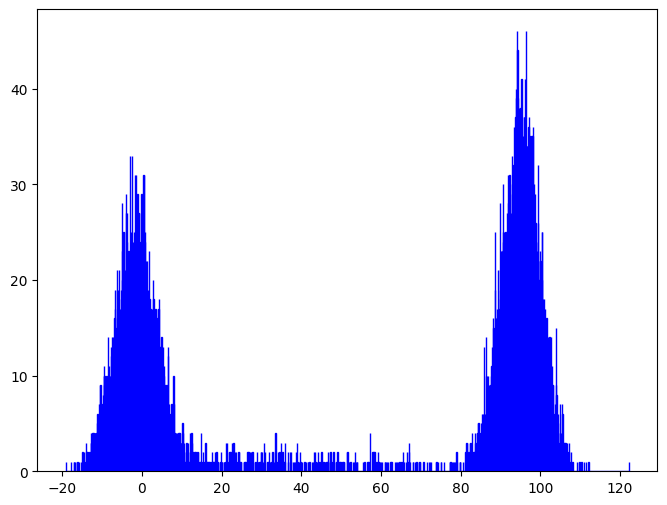

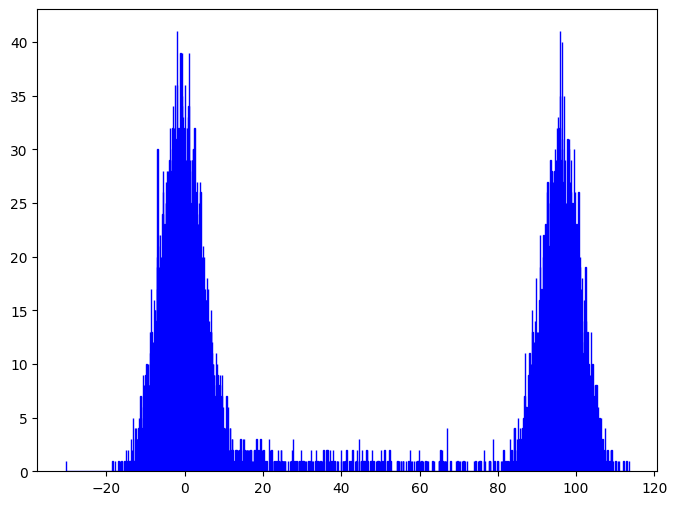

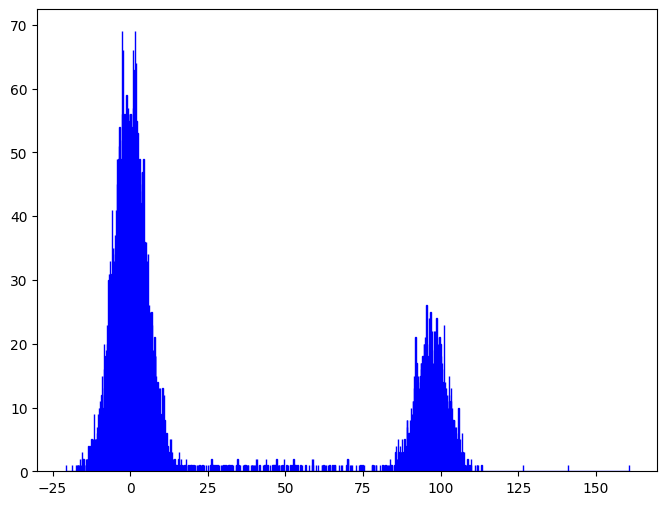

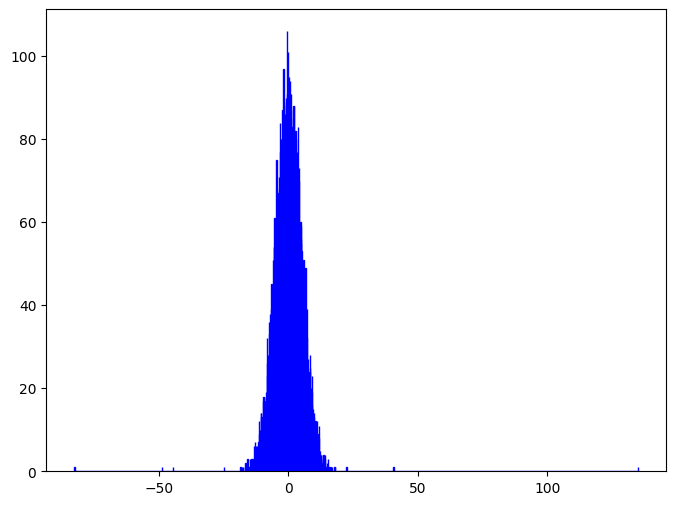

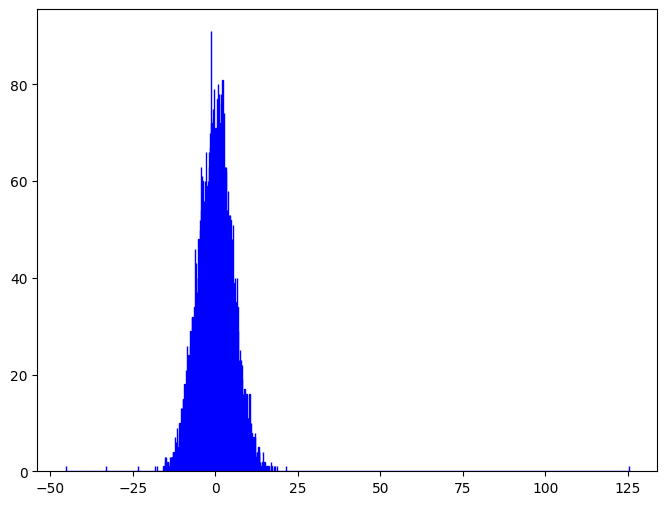

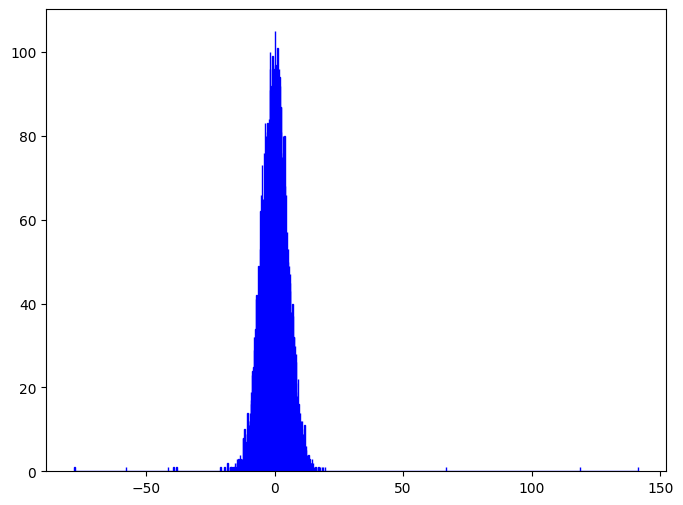

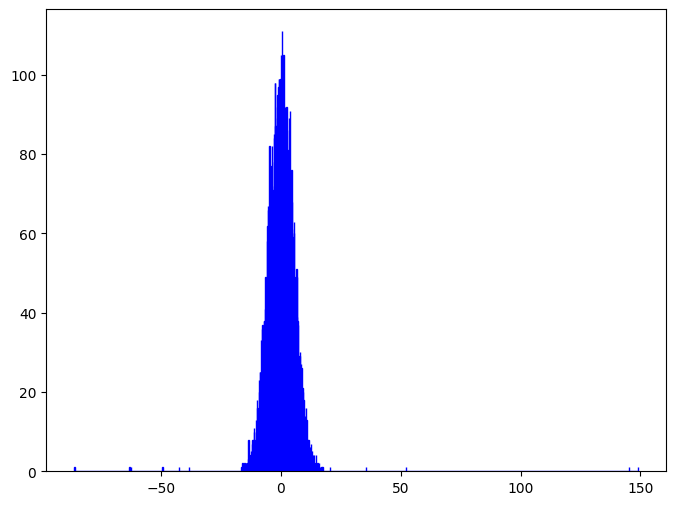

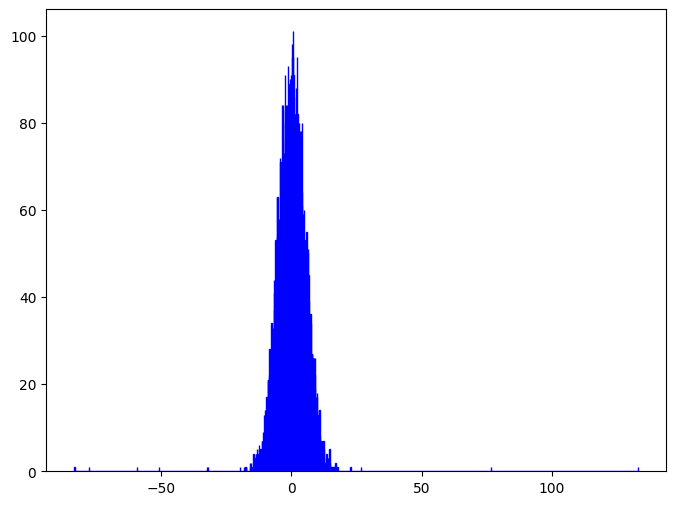

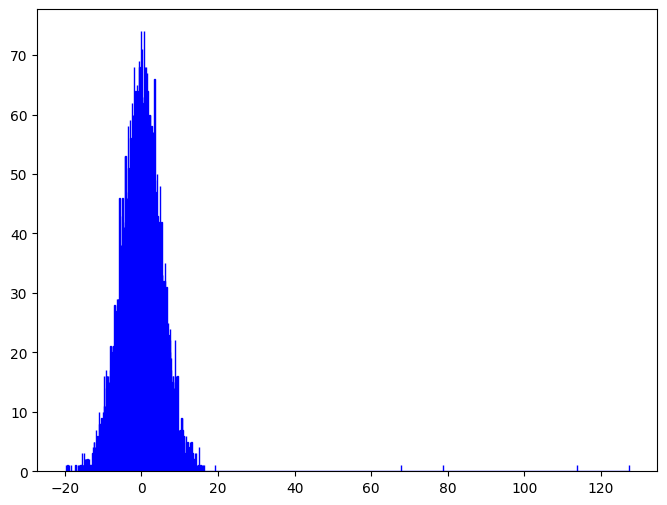

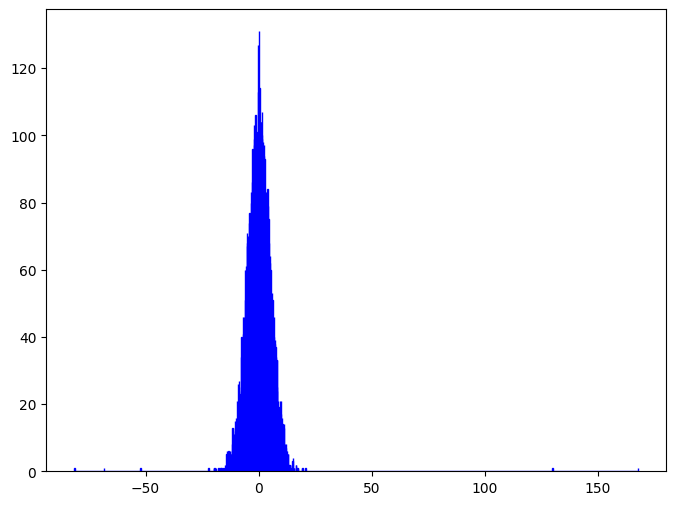

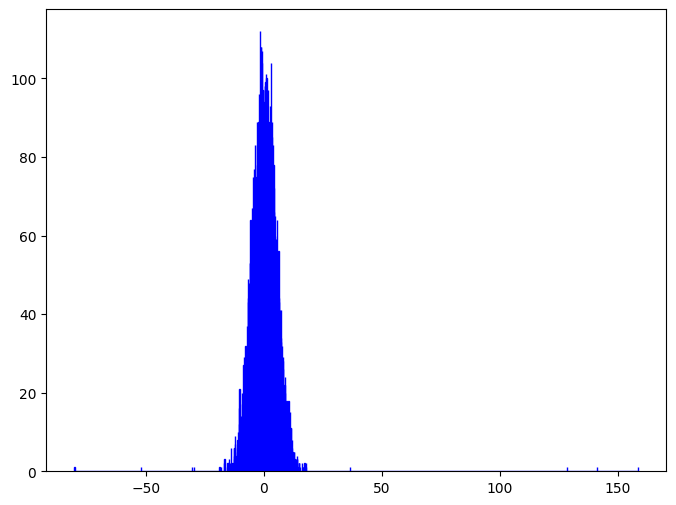

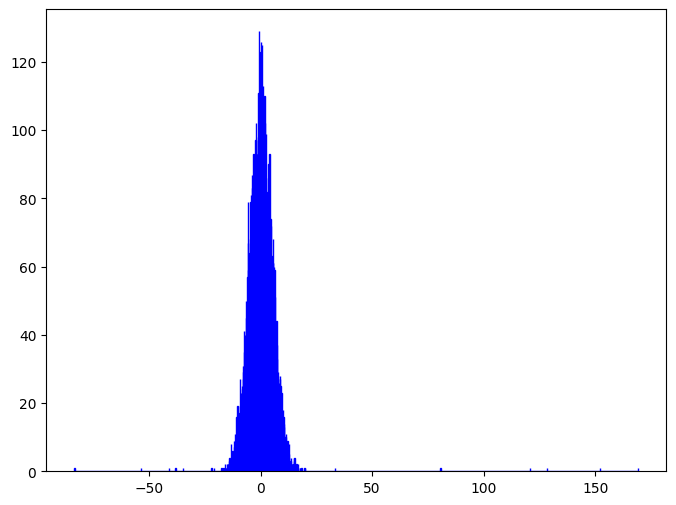

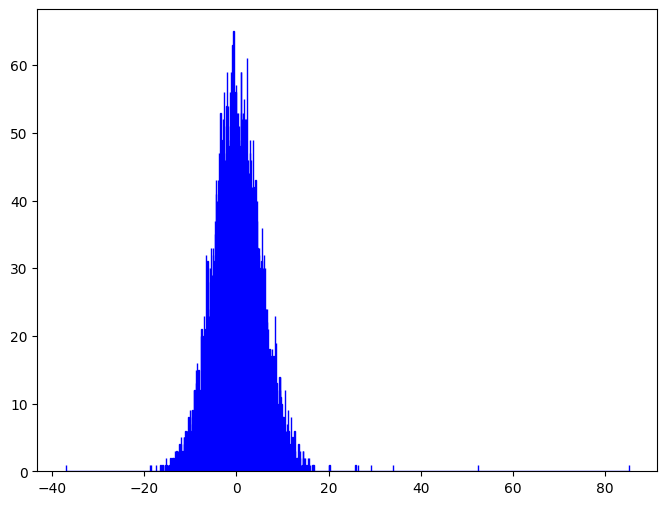

In [448]:
# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Initialize required variables
BendingAngle = bending_angle * 1.e6
print(f"The bending angle of the crystal is: {BendingAngle} murad")
efficiencies = []  # List to store calculated efficiencies
efficiencies_error = []
impacting_angle = []

# Loop over iterations for efficiency analysis
for iteration in tracking_data['iteration'].unique():
    # Extract data for the current iteration
    iteration_data = tracking_data[tracking_data['iteration'] == iteration]

    if iteration_data['angle'].isnull().any():
        print(f"Iteration {iteration}: Invalid 'angle' data. Skipping.")
        efficiencies.append(np.nan)
        continue

    # Calculate crystal angle
    crystal_angle = iteration_data['angle'].unique().item() * 1.e6
    print(f"The crystal angle is: {crystal_angle} murad")
    px_values = iteration_data['px'] * 1.e6 
    px_init_values = iteration_data['px_init'] *1.e6
    crystal_angle = iteration_data['angle'].unique().item() * 1.e6
    print(f"crystal_angle: {crystal_angle} mrad")   

    # Select only surviving particles and only within the window of interest
    mask = (px_values > -BendingAngle) & ((px_values - part_init.px) < BendingAngle * 2) & ((px_values - part_init.px) > -100)
    channeling_px = px_values[mask]   # Convert to µrad

    # Generate the histogram data for plotting and fitting
    counts, bin_edges = np.histogram(channeling_px, bins=2000, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    # Restrict fitting to the peak range
    mask_fit = (bin_centers >= crystal_angle + BendingAngle * 0.8) & (bin_centers <= crystal_angle + BendingAngle * 1.2)
    bin_centers_fit = bin_centers[mask_fit]
    counts_fit = counts[mask_fit]
    print(counts_fit)

    # Perform Gaussian fit within the specified range
    try:
        initial_guess = [np.max(counts_fit), crystal_angle + BendingAngle, 5]
        popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit, p0=initial_guess,
                       bounds=([0, BendingAngle*0.8 + crystal_angle, 1], [np.inf,  BendingAngle*1.2 + crystal_angle, 10]))
        print(f"Bin with biggest count: {np.argmax(counts_fit)}")

        # Extract fit parameters and errors
        amp, mean, sigma = popt
        amp_err, mean_err, sigma_err = np.sqrt(np.diag(pcov))

        # Calculate the integral (number of channeled particles) and its error
        integral = amp * sigma * np.sqrt(2 * np.pi) / bin_width                         #IMPORTANT TO DIVEDE BY BIN_WIDTH
        integral_error = integral * np.sqrt((amp_err / amp)**2 + (sigma_err / sigma)**2) 

        # Calculate efficiency for the main peak relative to total particles in the range
        efficiency = integral / num_part * 100
        if efficiency > 100:
            efficiency = 0
            efficiencies.append(efficiency)
        efficiencies.append(efficiency)
        print(f"Efficiency of {iteration} iteration: {efficiency:.2f}%")
    except Exception as e:
        # Handle any error by setting efficiency to 0
        efficiency = 0
        efficiencies.append(efficiency)
        print(f"Failed to calculate efficiency for iteration {iteration}. Setting efficiency to 0. Error: {e}")
        
     # Plot the histogram and the Gaussian fit only in the fitting range
    plt.figure(figsize=(8, 6))
    plt.hist(channeling_px, bins=2000, density=False, color='blue', edgecolor='blue')

    
    # Ideal efficiency calculated as particles insed range +- 3 sigma of the integral 
    lower_bound = mean - 3 * sigma
    upper_bound = mean + 3 * sigma
    particles_in_range = len(channeling_px[(channeling_px >= lower_bound) & (channeling_px <= upper_bound)])
    ideal_efficiency = (particles_in_range / num_part) * 100

    # Generate impacting angle data
    impacting_angle.append(min_angle + iteration * steps)
    #print(f"Impacting angle: {impacting_angle}")

    # Save efficiencies to DataFrame
    efficiency_data = pd.DataFrame({
    'impacting angle (muRad)': impacting_angle,
    'efficiency': efficiencies
    })

# Display efficiency data
print(efficiency_data)


In [449]:
efficiency_data

,impacting angle (muRad),efficiency
0,-20,5.060307e-01
1,-19,3.516551e-01
2,-18,3.660557e-01
3,-17,4.463870e-01
4,-16,4.529726e-01
5,-15,3.864189e-01
6,-14,4.627478e-01
7,-13,2.974872e-01
8,-12,2.423622e-01
9,-11,4.043402e-01


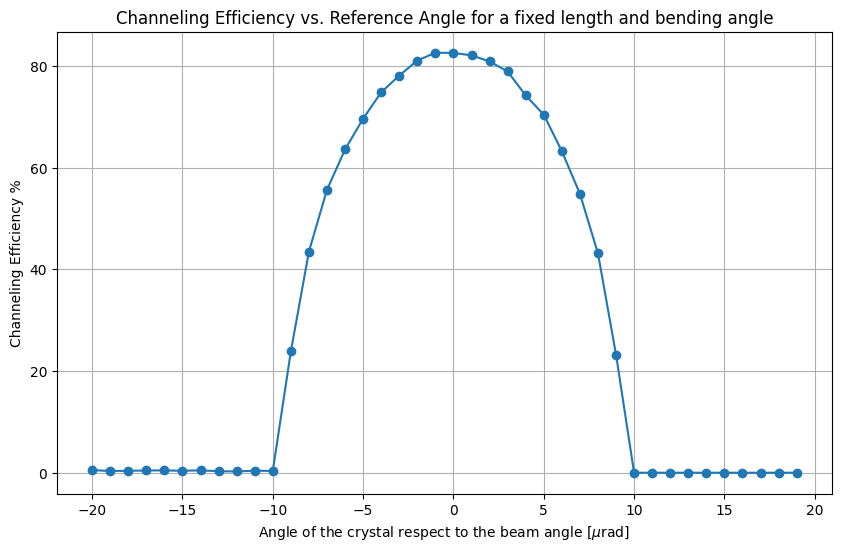

In [459]:
# Ensure efficiencies and bending angles are in the same order
efficiency_data['bending_angle'] = [angle for angle in impacting_angles]  

# Plot Channeling Efficiency vs Bending Angle
plt.figure(figsize=(10, 6))
plt.plot(efficiency_data['bending_angle']*1.e6, efficiency_data['efficiency'], marker='o', linestyle='-')

# Customize the plot
plt.title('Channeling Efficiency vs. Reference Angle for a fixed length and bending angle')
plt.xlabel(r'Angle of the crystal respect to the beam angle [$\mu$rad]')
plt.ylabel('Channeling Efficiency %')
plt.grid(True)
plt.show()

## Tests and debug

Let's see if initializing a bunch of particles passing through a crystal we can fit the channeling mode.

In [451]:
crystal = xc.EverestCrystal(length = 0.002,
material = xc.materials.SiliconCrystal,
bending_angle = 440e-6 / 5,
width = 0.002,
height = 0.05,
side = '+',
miscut = 0.0,
lattice = 'strip',
jaw = 0.001,         
#tilt = -1.9999999999999998e-05,  
tilt = 0 ,    
_context=context)

part = xp.Particles(
        _context=context,
        x=x_init,  
        px=px_init, 
        y=y_init,
        py=py_init,
        delta=0,
        p0c=4e11
    )
part_init = part.copy()


In [452]:
crystal.track(part)

88.0


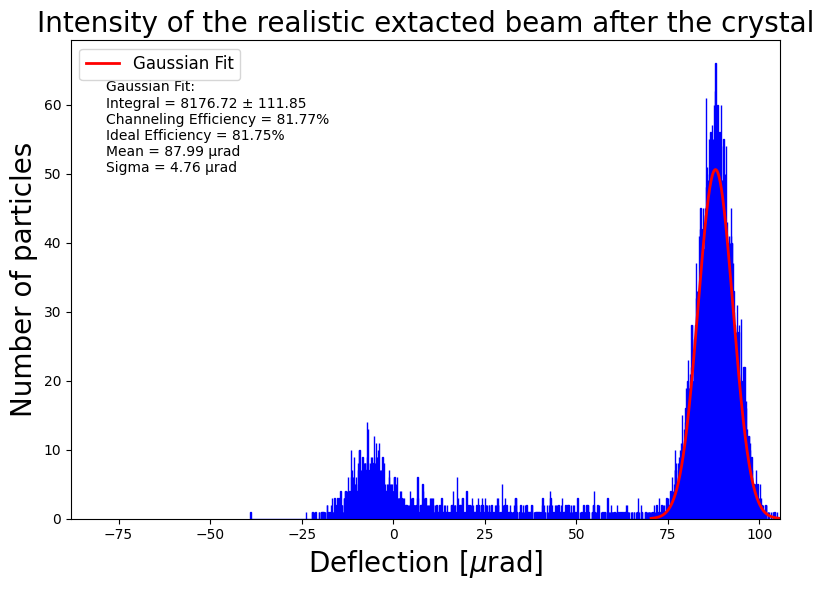

Number of channeled particles (integral of the fit): 8176.72 ± 111.85
Channeling Efficiency: 81.77%
Ideal Efficiency: 81.75%
Fit parameters: Amplitude = 50.58, Mean = 87.99, Sigma = 4.76


In [453]:
BendingAngle = crystal.bending_angle * 1.e6 #in Microrads
crystal_angle = crystal.tilt * 1.e6 #in Microrads
print(BendingAngle)


# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2))

# Select only surviving particles and only within the window of interest
mask = (part.state > 0) & ((part.px - part_init.px) < BendingAngle * 2) & ((part.px - part_init.px) > -100.e-6)
channeling_px = part.px[mask] * 1.e6  # Convert to µrad


# Generate the histogram data for plotting and fitting
counts, bin_edges = np.histogram(channeling_px, bins=2000, density=False)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Restrict fitting to the peak range (130 to 170 µrad)
mask_fit = (bin_centers >= crystal_angle + BendingAngle * 0.8) & (bin_centers <= crystal_angle + BendingAngle * 1.2)
bin_centers_fit = bin_centers[mask_fit]
counts_fit = counts[mask_fit]

# Perform Gaussian fit within the specified range
initial_guess = [np.max(counts_fit), crystal_angle + BendingAngle, 5]
popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit, p0=initial_guess,
                       bounds=([0, BendingAngle*0.8 + crystal_angle, 1], [np.inf,  BendingAngle*1.2 + crystal_angle, 10]))

# Extract fit parameters and errors
amp, mean, sigma = popt
amp_err, mean_err, sigma_err = np.sqrt(np.diag(pcov))

# Plot the histogram and the Gaussian fit only in the fitting range
plt.figure(figsize=(8, 6))
plt.hist(channeling_px, bins=2000, density=False, color='blue', edgecolor='blue')

# Plot the Gaussian fit 
plot_range = np.linspace(crystal_angle + BendingAngle*0.8, crystal_angle + BendingAngle*1.2, 500)
plt.plot(plot_range, gaussian(plot_range, *popt), color='red', linewidth=2, label="Gaussian Fit")

# Calculate the integral (number of channeled particles) and its error
integral = amp * sigma * np.sqrt(2 * np.pi) / bin_width                         #IMPORTANT TO DIVEDE BY BIN_WIDTH
integral_error = integral * np.sqrt((amp_err / amp)**2 + (sigma_err / sigma)**2)

# Calculate efficiency for the main peak relative to total particles in the range
efficiency = integral / num_part * 100
# Ideal efficiency calculated as particles insed range +- 3 sigma of the integral 
lower_bound = mean - 3 * sigma
upper_bound = mean + 3 * sigma
particles_in_range = len(channeling_px[(channeling_px >= lower_bound) & (channeling_px <= upper_bound)])
ideal_efficiency = (particles_in_range / num_part) * 100

# Display fit information on the plot
fit_info = (f"\n"
            f"Gaussian Fit:\n"
            f"Integral = {integral:.2f} ± {integral_error:.2f}\n"
            f"Channeling Efficiency = {efficiency:.2f}%\n"
            f"Ideal Efficiency = {ideal_efficiency:.2f}%\n"
            f"Mean = {mean:.2f} µrad\n"
            f"Sigma = {sigma:.2f} µrad")
plt.text(0.05, 0.95, fit_info, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

# Final plot adjustments
plt.xlabel(r'Deflection [$\mu$rad]', fontsize=20)
plt.xlim(crystal_angle - BendingAngle, crystal_angle + BendingAngle * 1.2)
plt.ylabel('Number of particles', fontsize=20)
plt.title(r'Intensity of the realistic extacted beam after the crystal', fontsize=20)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

# Print the results
print(f"Number of channeled particles (integral of the fit): {integral:.2f} ± {integral_error:.2f}")
print(f"Channeling Efficiency: {efficiency:.2f}%")
print(f"Ideal Efficiency: {ideal_efficiency:.2f}%")
print(f"Fit parameters: Amplitude = {amp:.2f}, Mean = {mean:.2f}, Sigma = {sigma:.2f}")


#### Let's try with the data that we have from before

Let's see if we can analyse just one iteration of the previous dataframe

In [460]:
iteration_data = tracking_data[tracking_data['iteration'] == 20]

In [461]:
crystal_angle = iteration_data['angle'].unique().item()

In [462]:
crystal_angle

0.0

In [463]:
iteration_data

,iteration,particle_id,x,px,px_init,angle
200000,20,0,0.002,8.548065e-05,0.0,0.0
200001,20,1,0.002,8.260721e-05,0.0,0.0
200002,20,2,0.002,9.038222e-05,0.0,0.0
200003,20,3,0.002,8.240025e-05,0.0,0.0
200004,20,4,0.002,8.010720e-05,0.0,0.0
...,...,...,...,...,...,...
209995,20,9995,0.002,-3.183991e-07,0.0,0.0
209996,20,9996,0.002,-1.002677e-05,0.0,0.0
209997,20,9997,0.002,3.541230e-05,0.0,0.0
209998,20,9998,0.002,-3.691481e-06,0.0,0.0


BendingAngle: 88.0 mrad
crystal_angle: 0.0 mrad
[ 0  0  1  1  0  0  0  2  1  0  2  1  0  1  0  0  0  0  1  1  1  0  0  1
  0  1  1  0  0  0  1  1  0  0  1  1  2  2  1  0  0  2  1  1  3  1  2  2
  2  0  1  1  2  2  0  1  2  2  0  1  2  3  1  0  2  1  1  0  1  2  4  4
  1  3  3  1  4  4  6  8  2  2  1  3  6  9  5  4  3  2  6  3  7  9  6  6
  3 10  9  3  9  6 13  8 13  9 12  6  9 10  7 10 13 13  7 11 12 20 11 15
 17 18  9 15 18 23 21 25 19 13 19 20 25 17 19 24 22 19 26 26 23 23 18 23
 34 26 32 28 30 33 31 29 25 25 20 25 28 32 36 31 45 41 38 33 44 38 31 27
 34 40 50 46 41 48 53 46 37 46 50 50 50 54 43 56 42 57 56 49 36 54 44 47
 48 60 55 55 68 58 50 59 56 63 51 63 57 51 71 60 47 40 49 58 57 49 58 57
 54 46 47 67 63 57 54 65 59 52 54 53 57 58 54 53 65 58 53 64 54 56 48 53
 47 40 52 59 43 59 45 54 45 49 43 43 44 52 40 39 47 44 46 36 37 45 47 41
 39 38 39 44 42 33 37 41 33 37 30 41 35 38 33 39 32 30 25 46 30 23 22 27
 29 24 26 26 16 28 23 26 16 25 21 21 21 25 24 13 17 18 10 10 10  9 11 23
 13

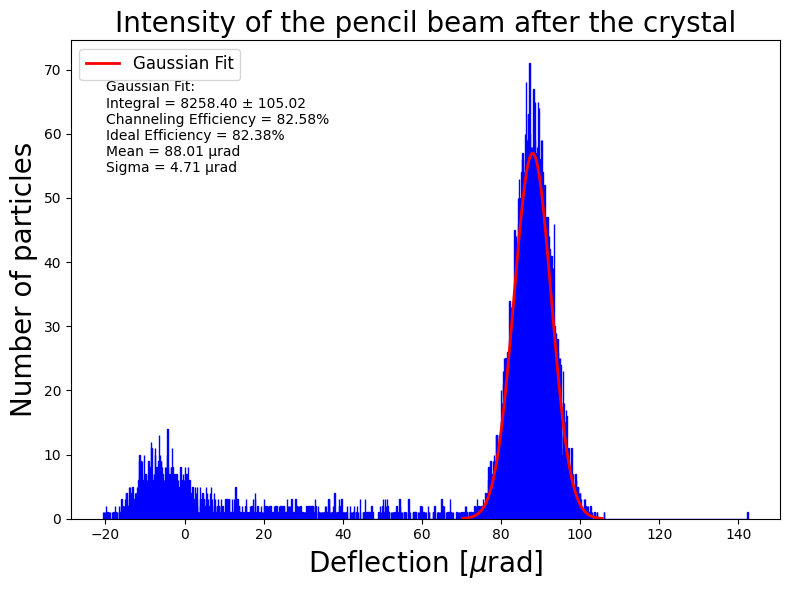

Number of channeled particles (integral of the fit): 8258.40 ± 105.02
Channeling Efficiency: 82.58%
Ideal Efficiency: 82.38%
Fit parameters: Amplitude = 56.96, Mean = 88.01, Sigma = 4.71


In [464]:
BendingAngle = crystal.bending_angle *1.e6
print(f"BendingAngle: {BendingAngle} mrad")


# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2))

px_values = iteration_data['px'] * 1.e6 
px_init_values = iteration_data['px_init'] *1.e6
crystal_angle = iteration_data['angle'].unique().item() * 1.e6
print(f"crystal_angle: {crystal_angle} mrad")   

# Select only surviving particles and only within the window of interest
mask = (px_values > -BendingAngle) & ((px_values - part_init.px) < BendingAngle * 2) & ((px_values - part_init.px) > -100)
channeling_px = px_values[mask]   # Convert to µrad

# Generate the histogram data for plotting and fitting
counts, bin_edges = np.histogram(channeling_px, bins=2000, density=False)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Restrict fitting to the peak range
mask_fit = (bin_centers >= crystal_angle + BendingAngle * 0.8) & (bin_centers <= crystal_angle + BendingAngle * 1.2)
bin_centers_fit = bin_centers[mask_fit]
counts_fit = counts[mask_fit]
print(counts_fit)

# Perform Gaussian fit within the specified range
initial_guess = [np.max(counts_fit), crystal_angle + BendingAngle, 5]
popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit, p0=initial_guess,
                       bounds=([0, BendingAngle*0.8 + crystal_angle, 1], [np.inf,  BendingAngle*1.2 + crystal_angle, 10]))
print(f"Bin with biggest count: {np.argmax(counts_fit)}")

# Extract fit parameters and errors
amp, mean, sigma = popt
amp_err, mean_err, sigma_err = np.sqrt(np.diag(pcov))

# Plot the histogram and the Gaussian fit only in the fitting range
plt.figure(figsize=(8, 6))
plt.hist(channeling_px, bins=2000, density=False, color='blue', edgecolor='blue')

# Plot the Gaussian fit 
plot_range = np.linspace(crystal_angle + BendingAngle*0.8, crystal_angle + BendingAngle*1.2, 2000)
plt.plot(plot_range, gaussian(plot_range, *popt), color='red', linewidth=2, label="Gaussian Fit")

# Calculate the integral (number of channeled particles) and its error
integral = amp * sigma * np.sqrt(2 * np.pi) / bin_width                         #IMPORTANT TO DIVEDE BY BIN_WIDTH
integral_error = integral * np.sqrt((amp_err / amp)**2 + (sigma_err / sigma)**2) 

# Calculate efficiency for the main peak relative to total particles in the range
efficiency = integral / num_part * 100
# Ideal efficiency calculated as particles insed range +- 3 sigma of the integral 
lower_bound = mean - 3 * sigma
upper_bound = mean + 3 * sigma
particles_in_range = len(channeling_px[(channeling_px >= lower_bound) & (channeling_px <= upper_bound)])
ideal_efficiency = (particles_in_range / num_part) * 100

# Display fit information on the plot
fit_info = (f"\n"
            f"Gaussian Fit:\n"
            f"Integral = {integral:.2f} ± {integral_error:.2f}\n"
            f"Channeling Efficiency = {efficiency:.2f}%\n"
            f"Ideal Efficiency = {ideal_efficiency:.2f}%\n"
            f"Mean = {mean:.2f} µrad\n"
            f"Sigma = {sigma:.2f} µrad")
plt.text(0.05, 0.95, fit_info, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

# Final plot adjustments
plt.xlabel(r'Deflection [$\mu$rad]', fontsize=20)
#plt.xlim(crystal_angle - BendingAngle, crystal_angle + BendingAngle * 1.2)
plt.ylabel('Number of particles', fontsize=20)
plt.title(r'Intensity of the pencil beam after the crystal', fontsize=20)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

# Print the results
print(f"Number of channeled particles (integral of the fit): {integral:.2f} ± {integral_error:.2f}")
print(f"Channeling Efficiency: {efficiency:.2f}%")
print(f"Ideal Efficiency: {ideal_efficiency:.2f}%")
print(f"Fit parameters: Amplitude = {amp:.2f}, Mean = {mean:.2f}, Sigma = {sigma:.2f}")
